In [599]:
import pandas as pd#استدعاء مكتبه بانداس
import numpy as np   # استدعاء مكتبة نمباي للحسابات الرياضيه
import matplotlib.pyplot as plt #استدعاء مكتبة متبلتليب
import seaborn as sns #استدعاء مكتبة سيبورن 

from sklearn.model_selection import train_test_split # تقسيم البيانات لتدريب واختبار
from sklearn.linear_model import LogisticRegression # موديل بسيط للتصنيف
from sklearn.ensemble import RandomForestClassifier # موديل قوي يعتمد على مجموعة أشجار
from sklearn.ensemble import GradientBoostingClassifier # موديل متقدم يحسن الأداء تدريجيا
from sklearn.tree import DecisionTreeClassifier  # شجرة قرارات للتصنيف
from sklearn.neighbors import KNeighborsClassifier # يعتمد على أقرب البيانات (neighbors)
from sklearn.naive_bayes import GaussianNB  # موديل احتمالات سريع وبسيط
from sklearn.svm import SVC # موديل قوي يفصل بين الفئات

from sklearn.metrics import accuracy_score


In [600]:
# 1. تحميل البيانات من ملفات CSV
train = pd.read_csv(r'D:\Computers and Information\Level 2\Second semester\Machine Learning\Section\PML\train.csv')
test = pd.read_csv(r'D:\Computers and Information\Level 2\Second semester\Machine Learning\Section\PML\test.csv')

## 1- Explore data

In [601]:
#train.head()
#train.tail(10)
train.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
805,806,0,3,"Johansson, Mr. Karl Johan",male,31.0,0,0,347063,7.775,NaN,S


In [602]:
train.shape

(891, 12)

In [603]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [604]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [605]:
nu =train.isnull().sum()
nu[nu>0]

Age         177
Cabin       687
Embarked      2
dtype: int64

<Axes: >

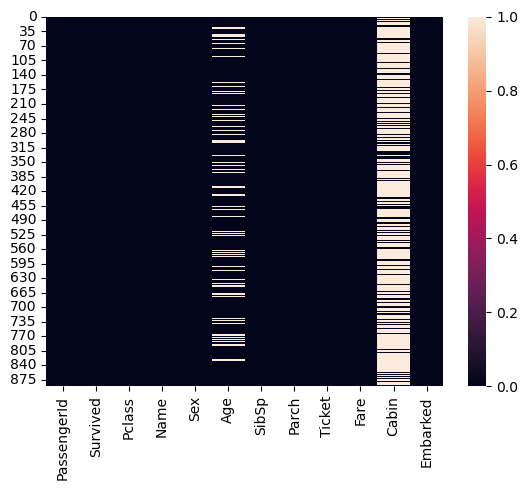

In [606]:
sns.heatmap(train.isnull())# تصور بياني ل ال null

## 2- Clean Data

In [607]:
def clean(d):

   d.drop(['Cabin','Name','Ticket','Embarked','Fare'] , axis=1 ,inplace=True) ##Delet columns
   d.Age= d.Age.fillna(d.Age.median())
   d.dropna()
   return d

In [608]:
clean(train)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch
0,1,0,3,male,22.0,1,0
1,2,1,1,female,38.0,1,0
2,3,1,3,female,26.0,0,0
3,4,1,1,female,35.0,1,0
4,5,0,3,male,35.0,0,0
...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0
887,888,1,1,female,19.0,0,0
888,889,0,3,female,28.0,1,2
889,890,1,1,male,26.0,0,0


In [609]:
clean(test)

,PassengerId,Pclass,Sex,Age,SibSp,Parch
0,892,3,male,34.5,0,0
1,893,3,female,47.0,1,0
2,894,2,male,62.0,0,0
3,895,3,male,27.0,0,0
4,896,3,female,22.0,1,1
...,...,...,...,...,...,...
413,1305,3,male,27.0,0,0
414,1306,1,female,39.0,0,0
415,1307,3,male,38.5,0,0
416,1308,3,male,27.0,0,0


<Axes: >

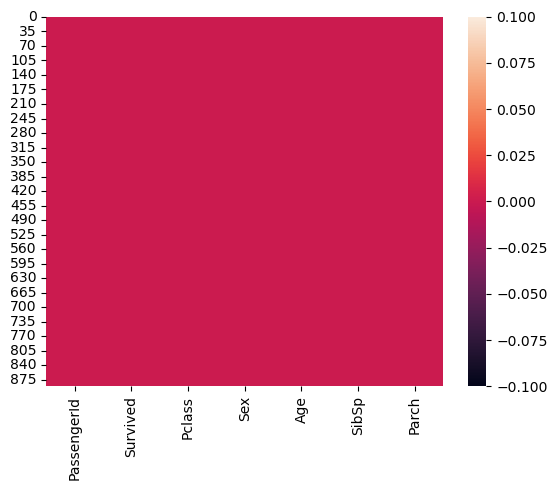

In [610]:
sns.heatmap(train.isnull())

## 3-Data Analysis

In [611]:
 co=train.corr() # علاقه بين البيانات

ValueError: could not convert string to float: 'male'

In [ ]:
sns.heatmap(co,annot=True, fmt='.1f',linewidths=0.5)

In [ ]:
train.Survived.value_counts()

In [ ]:
train.Sex.value_counts()

In [ ]:
train.Sex.value_counts().plot.pie()

In [ ]:
sns.countplot(data=train, x='Sex', hue='Survived')

In [ ]:
sns.countplot(data=train, x='Pclass' ,  hue='Survived')

In [ ]:
sns.histplot(train.Age)

## 4-Transform Data

In [ ]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1}).astype('uint8')
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1}).astype('uint8')    #modern

train[['Sex_female','Sex_male']] = train[['Sex_female','Sex_male']].astype('uint8') #1/0

train = pd.get_dummies(train, columns=['Sex'])
test = pd.get_dummies(test, columns=['Sex'])                #bool

In [ ]:
train.info()

In [ ]:
train

## 5-Creat Model

In [ ]:
x = train.drop(['Survived'], axis=1)
y= train.Survived

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8)

model1=DecisionTreeClassifier() #شجرة القرارات
model1.fit(x_train,y_train)#هنا الموديل “بيتعلم”بيشوف x_train (البيانات)ويقارنها بـ y_train (الإجابات)

pre=model1.predict(x_test)

accuracy_score(y_test,pre)

In [ ]:
accuracies=[]

In [ ]:
def all(model):
    model.fit(x_train,y_train)
    pre=model.predict(x_test)
    accuracy=accuracy_score(y_test,pre)
    print('Accuracy = ',accuracy)
    accuracies.append(accuracy)
    

In [ ]:
model1=LogisticRegression(max_iter=1000)
all(model1)

In [ ]:
model2=RandomForestClassifier() #   Trees  وفي الآخر بياخد تصويت الأغلبية 💡 كأنه لجنة حكّام بدل حكم واحد كل شجرة بتتوقع لوحدها   بيبني عدد كبير من Decision

                                
all(model2)

In [ ]:
model3=GradientBoostingClassifier()
all(model3)

In [ ]:
model4=DecisionTreeClassifier()
all(model4)

In [ ]:
model5=KNeighborsClassifier()
all(model5)

In [ ]:
model6=GaussianNB()
all(model6)

In [ ]:
model7=SVC()
all(model7)

In [ ]:

Algorithms = [
    'LogisticRegression',
    'RandomForestClassifier',
    'GradientBoostingClassifier',
    'DecisionTreeClassifier',
    'KNeighborsClassifier',
    'GaussianNB',
    'SVC'
]

for model in Algorithms:
    all(model)

In [ ]:
new=pd.DataFrame({'Algorithms':Algorithms,'accuracies' :accuracies})

In [ ]:
new

In [ ]:
modelx=GradientBoostingClassifier()
modelx.fit(x_train,y_train)

In [ ]:
lpre=modelx.predict(test)

In [ ]:
final=test.PassengerId

In [ ]:
new_dataframe=pd.DataFrame({'PassengerId':final,'Survivrd':lpre})

In [ ]:
new_dataframe.to_csv('submet.csv',index=False)

In [612]:
import os   #مكان الحفظ الحالي
os.getcwd()

'C:\\Users\\HP'